# EDA & Tests Statiques

In [55]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%matplotlib inline

In [4]:
train = pd.read_parquet('../data/processed/features_train.parquet')
TARGET = 'meteo_temperature_2m'
series = train[TARGET]
print(f'Train : {train.shape}')
print(f'Série : {series.index.min()} -> {series.index.max()}')

Train : (48118, 86)
Série : 2018-01-08 00:00:00 -> 2023-08-10 01:00:00


## Report overview

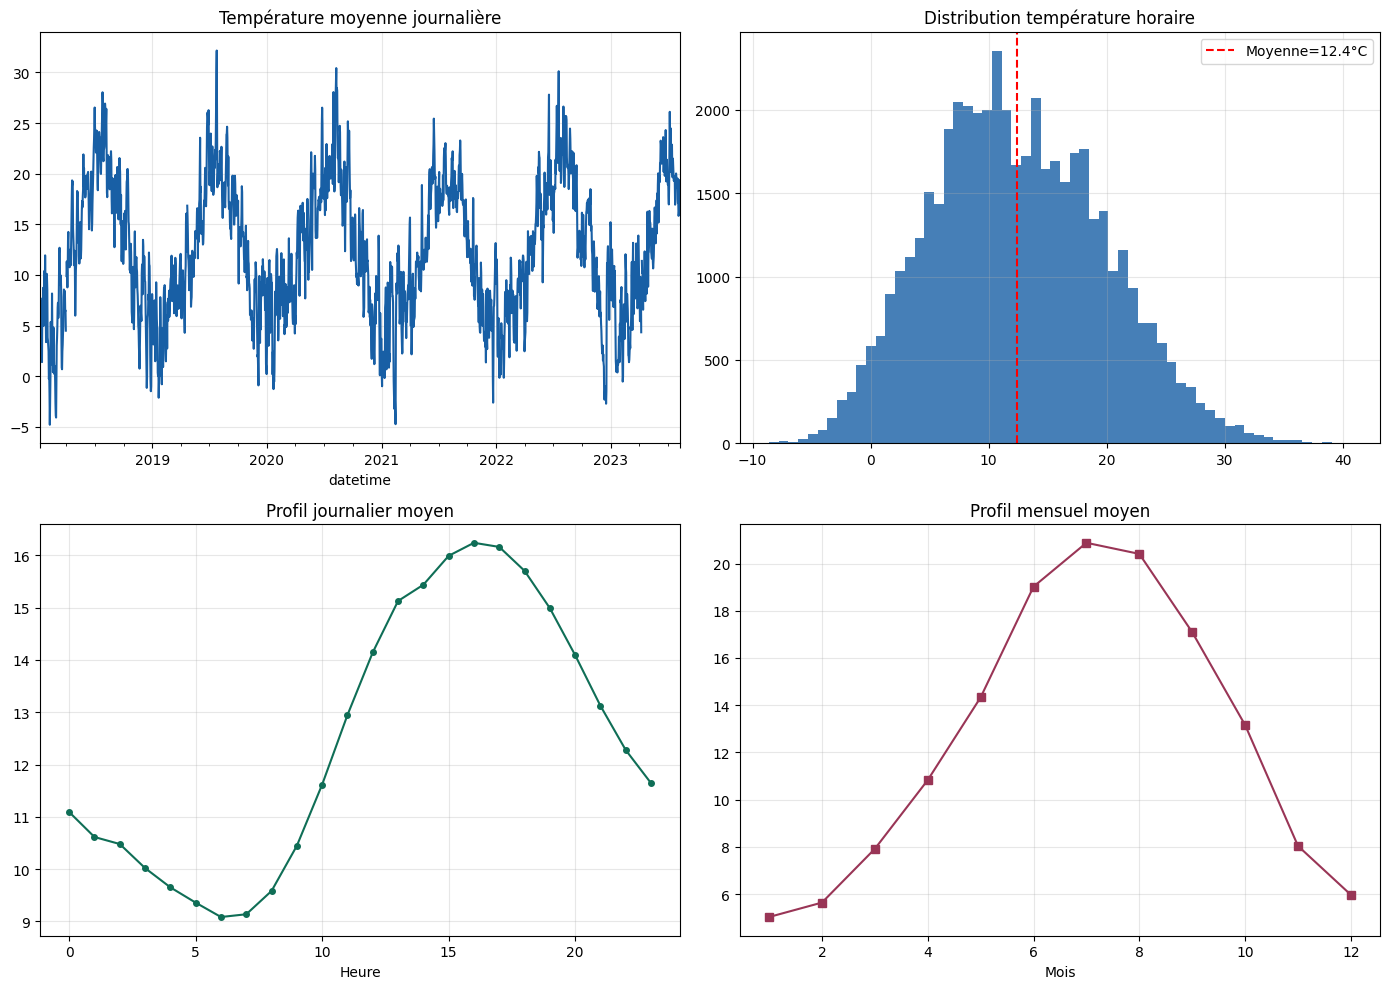

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Série complète
series.resample('D').mean().plot(ax=axes[0,0], title='Température moyenne journalière', color='#185FA5')
# Distribution
series.hist(bins=60, ax=axes[0,1], color='#185FA5', alpha=0.8)
axes[0,1].set_title('Distribution température horaire')
axes[0,1].axvline(series.mean(), color='red', linestyle='--', label=f'Moyenne={series.mean():.1f}°C')
axes[0,1].legend()
# Profil journalier moyen
hourly_avg = series.groupby(series.index.hour).mean()
hourly_avg.plot(ax=axes[1,0], title='Profil journalier moyen', color='#0F6E56', marker='o', ms=4)
axes[1,0].set_xlabel('Heure')
# Profil mensuel moyen
monthly_avg = series.groupby(series.index.month).mean()
monthly_avg.plot(ax=axes[1,1], title='Profil mensuel moyen', color='#993556', marker='s', ms=6)
axes[1,1].set_xlabel('Mois')
for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png', dpi=150)
plt.show()

## Tests Stationnarité

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

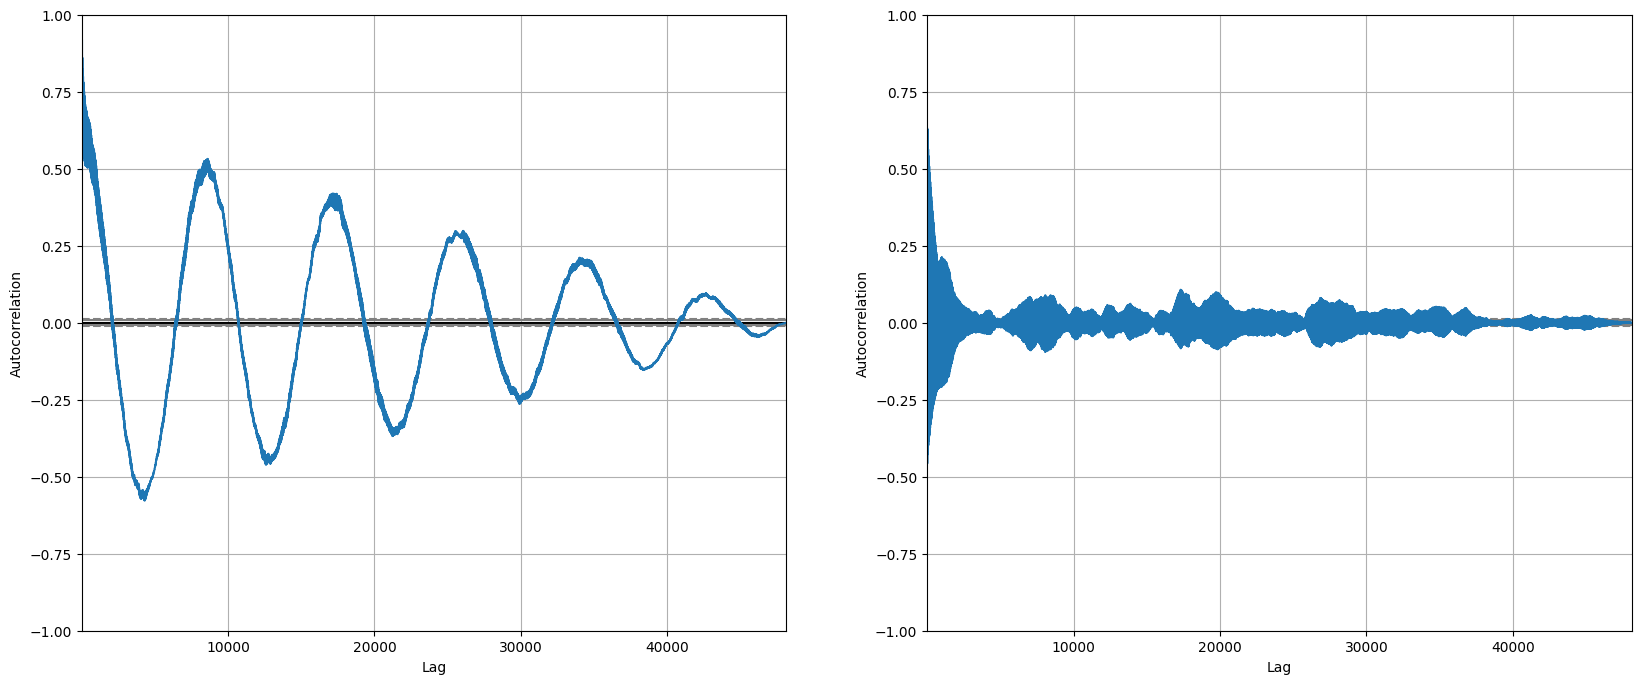

In [59]:
fig = plt.figure(figsize=(20,8), dpi = 100)
plt.subplot(121)
pd.plotting.autocorrelation_plot(series)
plt.subplot(122)
pd.plotting.autocorrelation_plot(series.diff().dropna())

In [10]:
from src.analysis.test_statiques import test_stationarity
stat_raw = test_stationarity(series, 'Temperature brute')
print(f"\nConclusion : {stat_raw['conclusion']}")


═══════════════════════════════════════════════════════
  Test stationnarité : Temperature brute
═══════════════════════════════════════════════════════

  ADF  | stat=-7.6594 | p=0.0000 | lags=57
Critique 1%: -3.4305 OK!!!
Critique 5%: -2.8616 OK!!!
Critique 10%: -2.5668 OK!!!

  KPSS | stat=0.3273 | p=0.1000 | lags=119
  ➜ Stationnaire (α=5%)

Conclusion : STATIONNAIRE

Conclusion : STATIONNAIRE


z:\TS_forcasting\notebooks\..\src\analysis\test_statiques.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean, regression="c", nlags="auto")


In [11]:
# Test sur la différence si nécessaire
if stat_raw['differencing_recommended']:
    stat_d1 = test_stationarity(series.diff().dropna(), 'Temperature diff(1h)')
    print(f"Diff(1h) : {stat_d1['conclusion']}")

## Décomposition STL

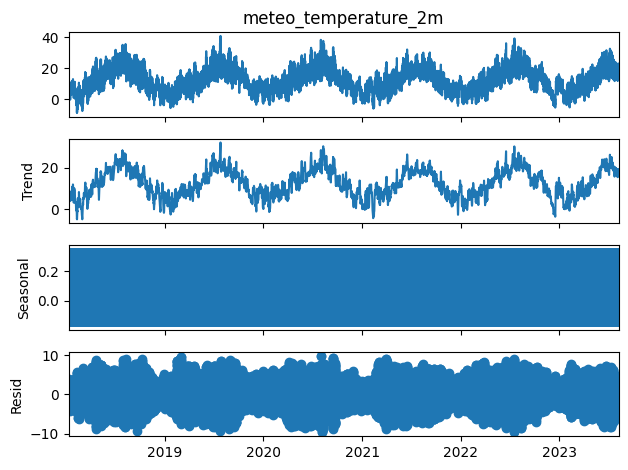

In [58]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(series, model='additive', period=24)
res.plot()
plt.show()

In [12]:
from src.analysis.test_statiques import decompose_stl
# Saisonnalité journalière (24h)
stl_daily = decompose_stl(series, period=24, output_dir='../reports/figures')
print(f"Force saisonnalité 24h : {stl_daily['seasonal_strength']:.4f}")
print(f"Force tendance         : {stl_daily['trend_strength']:.4f}")
print(f"Saisonnalité forte     : {stl_daily['strong_seasonality']}")


  STL Décomposition (période=24h)
    Force saisonnalité : 0.7744  [FORTE]
    Force tendance     : 0.9525  [FORTE]
Force saisonnalité 24h : 0.7744
Force tendance         : 0.9525
Saisonnalité forte     : True


## ACF / PACF

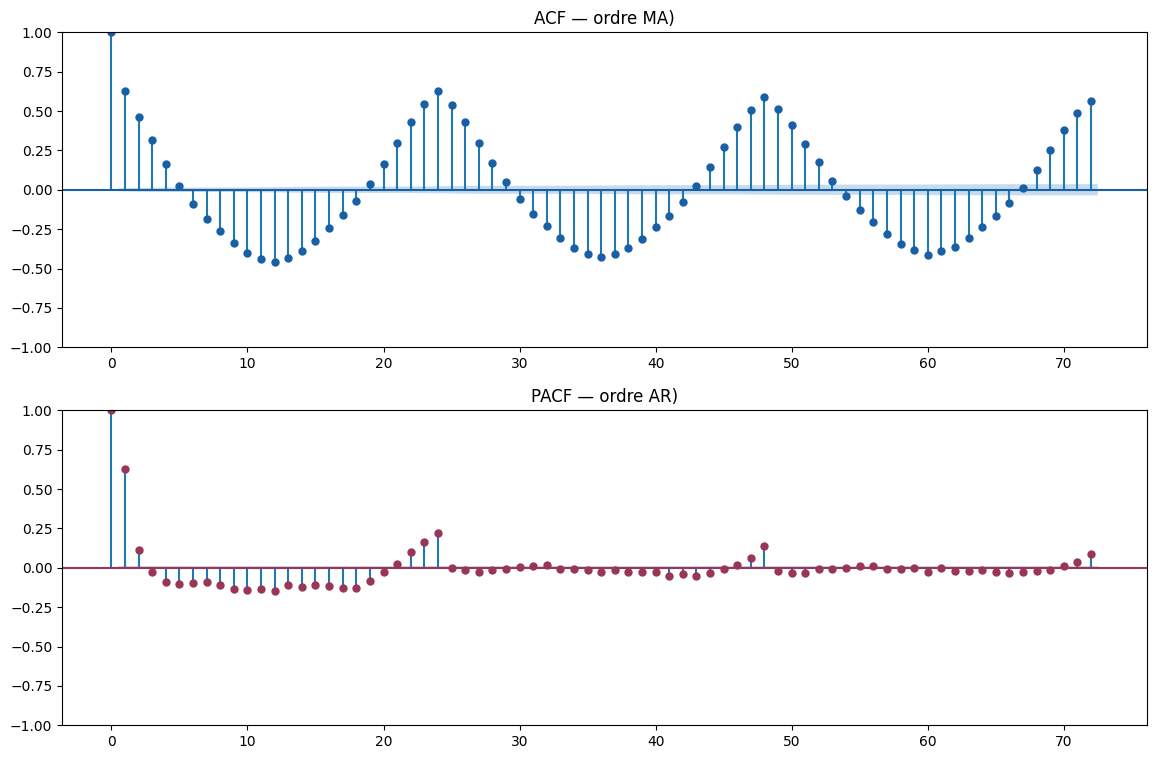

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))
plot_acf(series.diff().dropna(),  lags=72, ax=ax1, color="#185FA5",
            title=f"ACF — ordre MA)")
plot_pacf(series.diff().dropna(), lags=72, ax=ax2, color="#993556",
            title=f"PACF — ordre AR)")
plt.show()

In [44]:
from statsmodels.tsa.stattools  import acf, pacf

acf_vals, acf_conf = acf(series.diff().dropna(), nlags=72, alpha=0.05, fft=True)
pacf_vals, pacf_conf = pacf(series.diff().dropna(), nlags=72, alpha=0.05)

In [46]:
acf_conf[1, 0]

0.6208475460030565

## Casualité de Granger

Quelles variables météo 'causent' la température future ?

In [16]:
from src.analysis.test_statiques import granger_causality
candidates = ['meteo_relative_humidity_2m', 'meteo_wind_speed_10m',
              'meteo_shortwave_radiation', 'meteo_precipitation', 'meteo_surface_pressure']
candidates = [c for c in candidates if c in train.columns]
granger = granger_causality(train, TARGET, candidates, max_lag=24)

causing = [k for k, v in granger.items() if v['causes_target']]
print(f"\n{len(causing)}/{len(candidates)} variables causent la température")
print(f"Variables causales : {causing}")


  Causalité de Granger (meteo_temperature_2m)
  ─────────────────────────────────────────────
OK§§§ meteo_relative_humidity_2m                    p=0.0000  (lag=2)
OK§§§ meteo_wind_speed_10m                          p=0.0000  (lag=4)
OK§§§ meteo_shortwave_radiation                     p=0.0000  (lag=1)
meteo_precipitation : The x values include a column with constant values and so the test statistic cannot be computed.
OK§§§ meteo_surface_pressure                        p=0.0000  (lag=12)

  4/4 variables causent meteo_temperature_2m

4/5 variables causent la température
Variables causales : ['meteo_relative_humidity_2m', 'meteo_wind_speed_10m', 'meteo_shortwave_radiation', 'meteo_surface_pressure']


## Matrice de corrélation

In [15]:
meteo_base = [c for c in train.columns if c.startswith('meteo_') and 'lag' not in c and 'roll' not in c][:8]
corr_matrix = train[meteo_base].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Corrélations entre variables météo')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

## Résumé

In [17]:
print('='*55)
print('RECOMMANDATIONS pour la modélisation')
print('='*55)
print(f"  Différenciation d : {'1' if stat_raw['differencing_recommended'] else '0'}")
print(f"  Ordre AR   (p)   : {acf_res['suggested_p']}")
print(f"  Ordre MA   (q)   : {acf_res['suggested_q']}")
print(f"  Saisonnalité     : {stl_daily['strong_seasonality']} (24h)")
print(f"  Features clés    : {causing[:3]}")
print('→ Modèle recommandé : XGBoost avec lags + features météo')

RECOMMANDATIONS pour la modélisation
  Différenciation d : 0
  Ordre AR   (p)   : 72
  Ordre MA   (q)   : 72
  Saisonnalité     : True (24h)
  Features clés    : ['meteo_relative_humidity_2m', 'meteo_wind_speed_10m', 'meteo_shortwave_radiation']
→ Modèle recommandé : XGBoost avec lags + features météo
